# Spain vs France: Pre-Match xG Prediction

This notebook is an xG-focused companion experiment to the previous xT style and tactical matchup notebook. It uses only local StatsBomb Open Data files already downloaded under `archive/data`.

The goal is to estimate a pre-match expected-goals profile for Spain vs France and convert those projected goals into transparent 90-minute outcome probabilities. The notebook does **not** use current 2026 World Cup event data, lineups, injuries, media commentary, or outside current-form information.

Machine learning enters this workflow through StatsBomb's provided `shot.statsbomb_xg` value. That value is a supervised shot-quality estimate attached to each shot event. This notebook does not train a new xG model; it aggregates those existing shot-level xG values into team-match and pre-match estimates, then uses a Poisson score model for the final probability layer.

## 1. Configuration

The model uses senior men's historical proxy tournaments from local StatsBomb data: FIFA World Cup 2018 and 2022, plus UEFA Euro 2020 and 2024. The main model uses periods 1 and 2 only, excluding penalty shootouts by removing period 5. A sensitivity table also includes periods 1 through 4.

In [1]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except ImportError:
    display = print
    Markdown = lambda text: text

TARGET_MATCH = {
    "team_a": "Spain",
    "team_b": "France",
    "match_name": "Spain vs France",
    "competition_name": "2026 FIFA World Cup",
    "round_name": "Semifinal",
    "match_date": "2026-07-14",
    "neutral_site": True,
}

DATA_DIR = Path("archive/data")
OUTPUT_DIR = Path("outputs/spain_france_xg_prediction")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_COMPETITIONS = {
    ("FIFA World Cup", "2018"),
    ("FIFA World Cup", "2022"),
    ("UEFA Euro", "2020"),
    ("UEFA Euro", "2024"),
}

MAIN_PERIODS = [1, 2]
SENSITIVITY_PERIODS = [1, 2, 3, 4]
EXCLUDED_PERIODS = [5]
RECENT_MATCH_COUNT = 10
SHRINKAGE_MATCHES = 8
MAX_GOALS = 8
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print(f"StatsBomb data directory: {DATA_DIR.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")
print(json.dumps(TARGET_MATCH, indent=2))

c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


StatsBomb data directory: D:\UIUC\Projects\World Cup 2026\archive\data
Output directory: D:\UIUC\Projects\World Cup 2026\outputs\spain_france_xg_prediction
{
  "team_a": "Spain",
  "team_b": "France",
  "match_name": "Spain vs France",
  "competition_name": "2026 FIFA World Cup",
  "round_name": "Semifinal",
  "match_date": "2026-07-14",
  "neutral_site": true
}


## 2. Load and Inspect StatsBomb Data

This section reads `competitions.json`, filters to the selected senior men's international tournaments, loads the matching match metadata files, and checks that local event files are available.

In [2]:
if not DATA_DIR.exists():
    raise FileNotFoundError(f"StatsBomb data directory not found: {DATA_DIR}")

competitions_path = DATA_DIR / "competitions.json"
if not competitions_path.exists():
    raise FileNotFoundError(f"Missing competitions file: {competitions_path}")

competitions = pd.DataFrame(json.loads(competitions_path.read_text(encoding="utf-8")))
print(f"Competitions loaded: {competitions.shape}")
display(competitions.head())

selected_competitions = competitions[
    competitions.apply(
        lambda row: (row["competition_name"], str(row["season_name"])) in SELECTED_COMPETITIONS
        and row.get("competition_gender") == "male"
        and not bool(row.get("competition_youth")),
        axis=1,
    )
].copy()

print("Selected historical proxy competitions:")
display(selected_competitions[["competition_id", "season_id", "competition_name", "season_name", "competition_gender", "competition_youth"]])

if selected_competitions.empty:
    raise RuntimeError("No selected historical proxy competitions were found in local StatsBomb data.")

match_records = []
for _, comp in selected_competitions.iterrows():
    match_path = DATA_DIR / "matches" / str(comp["competition_id"]) / f"{comp['season_id']}.json"
    if not match_path.exists():
        warnings.warn(f"Missing match file: {match_path}")
        continue
    matches = json.loads(match_path.read_text(encoding="utf-8"))
    for match in matches:
        event_path = DATA_DIR / "events" / f"{match['match_id']}.json"
        match_records.append({
            "match_id": match["match_id"],
            "match_date": match.get("match_date"),
            "competition_id": comp["competition_id"],
            "season_id": comp["season_id"],
            "competition_name": comp["competition_name"],
            "season_name": str(comp["season_name"]),
            "home_team": match.get("home_team", {}).get("home_team_name"),
            "away_team": match.get("away_team", {}).get("away_team_name"),
            "home_score": match.get("home_score"),
            "away_score": match.get("away_score"),
            "match_file": str(match_path),
            "event_file": str(event_path),
            "event_file_exists": event_path.exists(),
        })

matches_df = pd.DataFrame(match_records).sort_values(["match_date", "match_id"]).reset_index(drop=True)
print(f"Selected matches loaded: {matches_df.shape}")
display(matches_df.head())
display(matches_df.tail())
print("Event file availability:")
display(matches_df["event_file_exists"].value_counts().rename_axis("event_file_exists").reset_index(name="count"))

Competitions loaded: (80, 12)


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,NaN,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882


Selected historical proxy competitions:


,competition_id,season_id,competition_name,season_name,competition_gender,competition_youth
30,43,106,FIFA World Cup,2022,male,False
31,43,3,FIFA World Cup,2018,male,False
73,55,282,UEFA Euro,2024,male,False
74,55,43,UEFA Euro,2020,male,False


Selected matches loaded: (230, 13)


,match_id,match_date,competition_id,season_id,competition_name,season_name,home_team,away_team,home_score,away_score,match_file,event_file,event_file_exists
0,7525,2018-06-14,43,3,FIFA World Cup,2018,Russia,Saudi Arabia,5,0,archive\data\matches\43\3.json,archive\data\events\7525.json,True
1,7576,2018-06-15,43,3,FIFA World Cup,2018,Portugal,Spain,3,3,archive\data\matches\43\3.json,archive\data\events\7576.json,True
2,7577,2018-06-15,43,3,FIFA World Cup,2018,Morocco,Iran,0,1,archive\data\matches\43\3.json,archive\data\events\7577.json,True
3,7578,2018-06-15,43,3,FIFA World Cup,2018,Egypt,Uruguay,0,1,archive\data\matches\43\3.json,archive\data\events\7578.json,True
4,7529,2018-06-16,43,3,FIFA World Cup,2018,Croatia,Nigeria,2,0,archive\data\matches\43\3.json,archive\data\events\7529.json,True


,match_id,match_date,competition_id,season_id,competition_name,season_name,home_team,away_team,home_score,away_score,match_file,event_file,event_file_exists
225,3942227,2024-07-06,55,282,UEFA Euro,2024,England,Switzerland,1,1,archive\data\matches\55\282.json,archive\data\events\3942227.json,True
226,3942382,2024-07-06,55,282,UEFA Euro,2024,Netherlands,Turkey,2,1,archive\data\matches\55\282.json,archive\data\events\3942382.json,True
227,3942752,2024-07-09,55,282,UEFA Euro,2024,Spain,France,2,1,archive\data\matches\55\282.json,archive\data\events\3942752.json,True
228,3942819,2024-07-10,55,282,UEFA Euro,2024,Netherlands,England,1,2,archive\data\matches\55\282.json,archive\data\events\3942819.json,True
229,3943043,2024-07-14,55,282,UEFA Euro,2024,Spain,England,2,1,archive\data\matches\55\282.json,archive\data\events\3943043.json,True


Event file availability:


,event_file_exists,count
0,True,230


## 3. Inspect Shot Event Schema

The notebook uses StatsBomb's provided shot-level `statsbomb_xg` field. This cell prints a representative shot event and confirms the available shot keys.

In [3]:
def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

example_shot = None
for event_file in matches_df.loc[matches_df["event_file_exists"], "event_file"]:
    events = load_json(event_file)
    for event in events:
        if event.get("type", {}).get("name") == "Shot":
            example_shot = event
            break
    if example_shot:
        break

if example_shot is None:
    raise RuntimeError("No shot events found in selected local StatsBomb events.")

print("Representative shot event fields:")
print("top-level keys:", sorted(example_shot.keys()))
print("shot keys:", sorted(example_shot.get("shot", {}).keys()))
print("team:", example_shot.get("team", {}).get("name"))
print("period:", example_shot.get("period"))
print("shot type:", example_shot.get("shot", {}).get("type", {}).get("name"))
print("shot outcome:", example_shot.get("shot", {}).get("outcome", {}).get("name"))
print("statsbomb_xg:", example_shot.get("shot", {}).get("statsbomb_xg"))

Representative shot event fields:
top-level keys: ['duration', 'id', 'index', 'location', 'minute', 'period', 'play_pattern', 'player', 'position', 'possession', 'possession_team', 'related_events', 'second', 'shot', 'team', 'timestamp', 'type']
shot keys: ['body_part', 'end_location', 'freeze_frame', 'key_pass_id', 'outcome', 'statsbomb_xg', 'technique', 'type']
team: Saudi Arabia
period: 1
shot type: Open Play
shot outcome: Blocked
statsbomb_xg: 0.011306748


## 4. Extract Team-Match xG

This section aggregates shot-level xG into team-match rows. The main dataset uses only periods 1 and 2. Penalty shootouts are excluded by construction because period 5 is never included.

In [4]:
def extract_match_xg(match_row, periods):
    events = load_json(match_row["event_file"])
    teams = [match_row["home_team"], match_row["away_team"]]
    xg = {team: 0.0 for team in teams}
    shots = {team: 0 for team in teams}
    shot_xg_present = {team: 0 for team in teams}
    excluded_shootout_shots = 0

    for event in events:
        if event.get("type", {}).get("name") != "Shot":
            continue
        period = event.get("period")
        if period in EXCLUDED_PERIODS:
            excluded_shootout_shots += 1
            continue
        if period not in periods:
            continue
        team = event.get("team", {}).get("name")
        if team not in xg:
            continue
        shots[team] += 1
        shot_value = event.get("shot", {}).get("statsbomb_xg")
        if shot_value is not None:
            xg[team] += float(shot_value)
            shot_xg_present[team] += 1

    rows = []
    home = match_row["home_team"]
    away = match_row["away_team"]
    score = {
        home: match_row["home_score"],
        away: match_row["away_score"],
    }
    for team, opponent in [(home, away), (away, home)]:
        rows.append({
            "team": team,
            "opponent": opponent,
            "match_id": match_row["match_id"],
            "match_date": match_row["match_date"],
            "competition_name": match_row["competition_name"],
            "season_name": match_row["season_name"],
            "periods_included": ",".join(map(str, periods)),
            "xg_for": xg[team],
            "xg_against": xg[opponent],
            "shots_for": shots[team],
            "shots_against": shots[opponent],
            "shot_xg_present_for": shot_xg_present[team],
            "shot_xg_present_against": shot_xg_present[opponent],
            "goals_for": score[team],
            "goals_against": score[opponent],
            "is_target_team": team in [TARGET_MATCH["team_a"], TARGET_MATCH["team_b"]],
            "event_file": match_row["event_file"],
            "excluded_period_5_shots_in_match": excluded_shootout_shots,
        })
    return rows

main_rows = []
sensitivity_rows = []
for _, match_row in matches_df[matches_df["event_file_exists"]].iterrows():
    main_rows.extend(extract_match_xg(match_row, MAIN_PERIODS))
    sensitivity_rows.extend(extract_match_xg(match_row, SENSITIVITY_PERIODS))

team_xg_dataset = pd.DataFrame(main_rows).sort_values(["match_date", "match_id", "team"]).reset_index(drop=True)
team_xg_sensitivity_dataset = pd.DataFrame(sensitivity_rows).sort_values(["match_date", "match_id", "team"]).reset_index(drop=True)

team_xg_dataset.to_csv(OUTPUT_DIR / "prematch_team_xg_dataset.csv", index=False)
team_xg_sensitivity_dataset.to_csv(OUTPUT_DIR / "prematch_team_xg_dataset_periods_1_to_4.csv", index=False)

print(f"Main team-match xG rows: {team_xg_dataset.shape}")
display(team_xg_dataset.head())
print("Target-team rows:")
display(team_xg_dataset[team_xg_dataset["is_target_team"]].tail(20))
print("Period 5 shootout shots excluded in selected matches:")
print(int(team_xg_dataset.drop_duplicates("match_id")["excluded_period_5_shots_in_match"].sum()))

Main team-match xG rows: (460, 18)


,team,opponent,match_id,match_date,competition_name,season_name,periods_included,xg_for,xg_against,shots_for,shots_against,shot_xg_present_for,shot_xg_present_against,goals_for,goals_against,is_target_team,event_file,excluded_period_5_shots_in_match
0,Russia,Saudi Arabia,7525,2018-06-14,FIFA World Cup,2018,"1,2",1.281601,0.248806,14,6,14,6,5,0,False,archive\data\events\7525.json,0
1,Saudi Arabia,Russia,7525,2018-06-14,FIFA World Cup,2018,"1,2",0.248806,1.281601,6,14,6,14,0,5,False,archive\data\events\7525.json,0
2,Portugal,Spain,7576,2018-06-15,FIFA World Cup,2018,"1,2",1.434596,1.660947,10,12,10,12,3,3,False,archive\data\events\7576.json,0
3,Spain,Portugal,7576,2018-06-15,FIFA World Cup,2018,"1,2",1.660947,1.434596,12,10,12,10,3,3,True,archive\data\events\7576.json,0
4,Iran,Morocco,7577,2018-06-15,FIFA World Cup,2018,"1,2",0.697556,1.059195,8,14,8,14,1,0,False,archive\data\events\7577.json,0


Target-team rows:


,team,opponent,match_id,match_date,competition_name,season_name,periods_included,xg_for,xg_against,shots_for,shots_against,shot_xg_present_for,shot_xg_present_against,goals_for,goals_against,is_target_team,event_file,excluded_period_5_shots_in_match
308,France,Tunisia,3857275,2022-11-30,FIFA World Cup,2022,"1,2",0.476989,0.298347,10,5,10,5,0,1,True,archive\data\events\3857275.json,0
311,Spain,Japan,3857255,2022-12-01,FIFA World Cup,2022,"1,2",0.857712,1.157801,12,6,12,6,1,2,True,archive\data\events\3857255.json,0
332,France,Poland,3869152,2022-12-04,FIFA World Cup,2022,"1,2",1.126374,1.593527,16,12,16,12,3,1,True,archive\data\events\3869152.json,0
339,Spain,Morocco,3869220,2022-12-06,FIFA World Cup,2022,"1,2",0.172571,0.436044,6,4,6,4,0,0,True,archive\data\events\3869220.json,7
347,France,England,3869354,2022-12-10,FIFA World Cup,2022,"1,2",0.839362,2.352551,8,16,8,16,2,1,True,archive\data\events\3869354.json,0
352,France,Morocco,3869552,2022-12-14,FIFA World Cup,2022,"1,2",2.002449,1.230364,14,13,14,13,2,0,True,archive\data\events\3869552.json,0
357,France,Argentina,3869685,2022-12-18,FIFA World Cup,2022,"1,2",1.157815,1.621734,6,12,6,12,3,3,True,archive\data\events\3869685.json,8
363,Spain,Croatia,3930160,2024-06-15,UEFA Euro,2024,"1,2",1.567183,2.482099,11,16,11,16,3,0,True,archive\data\events\3930160.json,0
375,France,Austria,3930165,2024-06-17,UEFA Euro,2024,"1,2",1.904532,0.748317,14,5,14,5,1,0,True,archive\data\events\3930165.json,0
393,Spain,Italy,3930172,2024-06-20,UEFA Euro,2024,"1,2",1.533880,0.143399,20,4,20,4,1,0,True,archive\data\events\3930172.json,0


Period 5 shootout shots excluded in selected matches:
142


## 5. Historical Proxy Selection

Spain and France are selected from the team-match xG dataset. The model uses the most recent available historical proxy matches, with recency weights that increase linearly from oldest to newest.

In [5]:
def weighted_average(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights)
    if valid.sum() == 0 or weights[valid].sum() <= 0:
        return np.nan
    return float(np.average(values[valid], weights=weights[valid]))

def recent_team_profile(dataset, team, recent_match_count=RECENT_MATCH_COUNT):
    rows = dataset[dataset["team"] == team].copy()
    if rows.empty:
        raise RuntimeError(f"No historical proxy xG rows found for {team}.")
    rows["match_date"] = pd.to_datetime(rows["match_date"])
    rows = rows.sort_values(["match_date", "match_id"]).tail(recent_match_count).reset_index(drop=True)
    rows["recency_weight"] = np.arange(1, len(rows) + 1)
    profile = {
        "team": team,
        "sample_matches": len(rows),
        "first_match_date": rows["match_date"].min().date().isoformat(),
        "last_match_date": rows["match_date"].max().date().isoformat(),
        "weighted_xg_for": weighted_average(rows["xg_for"], rows["recency_weight"]),
        "weighted_xg_against": weighted_average(rows["xg_against"], rows["recency_weight"]),
        "weighted_shots_for": weighted_average(rows["shots_for"], rows["recency_weight"]),
        "weighted_shots_against": weighted_average(rows["shots_against"], rows["recency_weight"]),
        "weighted_goals_for": weighted_average(rows["goals_for"], rows["recency_weight"]),
        "weighted_goals_against": weighted_average(rows["goals_against"], rows["recency_weight"]),
        "unweighted_xg_for": float(rows["xg_for"].mean()),
        "unweighted_xg_against": float(rows["xg_against"].mean()),
        "matches_used": "; ".join(
            f"{r.match_date.date().isoformat()} {r.team} vs {r.opponent} ({r.competition_name} {r.season_name})"
            for r in rows.itertuples()
        ),
    }
    return profile, rows

spain_profile, spain_recent_matches = recent_team_profile(team_xg_dataset, TARGET_MATCH["team_a"])
france_profile, france_recent_matches = recent_team_profile(team_xg_dataset, TARGET_MATCH["team_b"])

recent_profiles = pd.DataFrame([spain_profile, france_profile])
print("Recent weighted profiles:")
display(recent_profiles)
print("Spain recent matches:")
display(spain_recent_matches)
print("France recent matches:")
display(france_recent_matches)

Recent weighted profiles:


,team,sample_matches,first_match_date,last_match_date,weighted_xg_for,weighted_xg_against,weighted_shots_for,weighted_shots_against,weighted_goals_for,weighted_goals_against,unweighted_xg_for,unweighted_xg_against,matches_used
0,Spain,10,2022-11-27,2024-07-14,1.283842,0.797815,15.345455,9.200000,1.963636,0.709091,1.157882,0.877625,2022-11-27 Spain vs Germany (FIFA World Cup 20...
1,France,10,2022-12-04,2024-07-09,1.238002,0.853691,13.963636,8.545455,1.000000,0.763636,1.291644,1.101863,2022-12-04 France vs Poland (FIFA World Cup 20...


Spain recent matches:


,team,opponent,match_id,match_date,competition_name,season_name,periods_included,xg_for,xg_against,shots_for,shots_against,shot_xg_present_for,shot_xg_present_against,goals_for,goals_against,is_target_team,event_file,excluded_period_5_shots_in_match,recency_weight
0,Spain,Germany,3857263,2022-11-27,FIFA World Cup,2022,"1,2",0.639501,1.146952,7,11,7,11,1,1,True,archive\data\events\3857263.json,0,1
1,Spain,Japan,3857255,2022-12-01,FIFA World Cup,2022,"1,2",0.857712,1.157801,12,6,12,6,1,2,True,archive\data\events\3857255.json,0,2
2,Spain,Morocco,3869220,2022-12-06,FIFA World Cup,2022,"1,2",0.172571,0.436044,6,4,6,4,0,0,True,archive\data\events\3869220.json,7,3
3,Spain,Croatia,3930160,2024-06-15,UEFA Euro,2024,"1,2",1.567183,2.482099,11,16,11,16,3,0,True,archive\data\events\3930160.json,0,4
4,Spain,Italy,3930172,2024-06-20,UEFA Euro,2024,"1,2",1.533880,0.143399,20,4,20,4,1,0,True,archive\data\events\3930172.json,0,5
5,Spain,Albania,3930179,2024-06-24,UEFA Euro,2024,"1,2",0.951713,0.503154,16,10,16,10,1,0,True,archive\data\events\3930179.json,0,6
6,Spain,Georgia,3941018,2024-06-30,UEFA Euro,2024,"1,2",2.764726,0.113078,35,4,35,4,4,1,True,archive\data\events\3941018.json,0,7
7,Spain,Germany,3942226,2024-07-05,UEFA Euro,2024,"1,2",0.878302,1.216579,12,16,12,16,2,1,True,archive\data\events\3942226.json,0,8
8,Spain,France,3942752,2024-07-09,UEFA Euro,2024,"1,2",0.421516,0.850765,6,9,6,9,2,1,True,archive\data\events\3942752.json,0,9
9,Spain,England,3943043,2024-07-14,UEFA Euro,2024,"1,2",1.791713,0.726378,16,9,16,9,2,1,True,archive\data\events\3943043.json,0,10


France recent matches:


,team,opponent,match_id,match_date,competition_name,season_name,periods_included,xg_for,xg_against,shots_for,shots_against,shot_xg_present_for,shot_xg_present_against,goals_for,goals_against,is_target_team,event_file,excluded_period_5_shots_in_match,recency_weight
0,France,Poland,3869152,2022-12-04,FIFA World Cup,2022,"1,2",1.126374,1.593527,16,12,16,12,3,1,True,archive\data\events\3869152.json,0,1
1,France,England,3869354,2022-12-10,FIFA World Cup,2022,"1,2",0.839362,2.352551,8,16,8,16,2,1,True,archive\data\events\3869354.json,0,2
2,France,Morocco,3869552,2022-12-14,FIFA World Cup,2022,"1,2",2.002449,1.230364,14,13,14,13,2,0,True,archive\data\events\3869552.json,0,3
3,France,Argentina,3869685,2022-12-18,FIFA World Cup,2022,"1,2",1.157815,1.621734,6,12,6,12,3,3,True,archive\data\events\3869685.json,8,4
4,France,Austria,3930165,2024-06-17,UEFA Euro,2024,"1,2",1.904532,0.748317,14,5,14,5,1,0,True,archive\data\events\3930165.json,0,5
5,France,Netherlands,3930173,2024-06-21,UEFA Euro,2024,"1,2",1.218402,0.738183,15,9,15,9,0,0,True,archive\data\events\3930173.json,0,6
6,France,Poland,3938643,2024-06-25,UEFA Euro,2024,"1,2",1.891468,1.179094,19,10,19,10,1,1,True,archive\data\events\3938643.json,0,7
7,France,Belgium,3941019,2024-07-01,UEFA Euro,2024,"1,2",1.262012,0.363214,19,5,19,5,1,0,True,archive\data\events\3941019.json,0,8
8,France,Portugal,3942349,2024-07-05,UEFA Euro,2024,"1,2",0.663256,0.770125,15,10,15,10,0,0,True,archive\data\events\3942349.json,9,9
9,France,Spain,3942752,2024-07-09,UEFA Euro,2024,"1,2",0.850765,0.421516,9,6,9,6,1,2,True,archive\data\events\3942752.json,0,10


## 6. Pre-Match xG Model

The pre-match model estimates each team's attacking xG and defensive xG allowed, then shrinks those values toward the global tournament average. The final projected xG combines one team's shrunken attack with the opponent's shrunken defense. No home advantage is added because the match is configured as neutral site.

In [6]:
global_average_xg = float(team_xg_dataset["xg_for"].mean())
global_average_shots = float(team_xg_dataset["shots_for"].mean())

def shrink_to_global(value, sample_matches, global_mean=global_average_xg, shrinkage_matches=SHRINKAGE_MATCHES):
    if not np.isfinite(value):
        return global_mean
    return float((value * sample_matches + global_mean * shrinkage_matches) / (sample_matches + shrinkage_matches))

def add_shrunk_profile(profile):
    profile = dict(profile)
    n = profile["sample_matches"]
    profile["global_average_xg"] = global_average_xg
    profile["shrunk_attack_xg"] = shrink_to_global(profile["weighted_xg_for"], n)
    profile["shrunk_defense_xg_allowed"] = shrink_to_global(profile["weighted_xg_against"], n)
    profile["attack_rating_vs_global"] = profile["shrunk_attack_xg"] / global_average_xg if global_average_xg > 0 else np.nan
    profile["defense_allowed_rating_vs_global"] = profile["shrunk_defense_xg_allowed"] / global_average_xg if global_average_xg > 0 else np.nan
    return profile

spain_model_profile = add_shrunk_profile(spain_profile)
france_model_profile = add_shrunk_profile(france_profile)

def projected_xg_for(team_profile, opponent_profile):
    # Geometric mean keeps attack and opponent defensive allowance symmetric and positive.
    return float(math.sqrt(max(team_profile["shrunk_attack_xg"], 0) * max(opponent_profile["shrunk_defense_xg_allowed"], 0)))

spain_projected_xg = projected_xg_for(spain_model_profile, france_model_profile)
france_projected_xg = projected_xg_for(france_model_profile, spain_model_profile)

xg_inputs = pd.DataFrame([spain_model_profile, france_model_profile])
xg_inputs["projected_match_xg"] = xg_inputs["team"].map({
    TARGET_MATCH["team_a"]: spain_projected_xg,
    TARGET_MATCH["team_b"]: france_projected_xg,
})
xg_inputs["model_note"] = (
    "Projected xG combines recency-weighted, globally-shrunk team attack with opponent defensive xG allowed; "
    "neutral-site assumption; periods 1 and 2 only."
)
xg_inputs.to_csv(OUTPUT_DIR / "spain_france_xg_inputs.csv", index=False)

print(f"Global average xG per team-match: {global_average_xg:.3f}")
print(f"Spain projected xG: {spain_projected_xg:.3f}")
print(f"France projected xG: {france_projected_xg:.3f}")
display(xg_inputs)

assert np.isfinite(spain_projected_xg) and spain_projected_xg >= 0
assert np.isfinite(france_projected_xg) and france_projected_xg >= 0

Global average xG per team-match: 1.217
Spain projected xG: 1.129
France projected xG: 1.100


,team,sample_matches,first_match_date,last_match_date,weighted_xg_for,weighted_xg_against,weighted_shots_for,weighted_shots_against,weighted_goals_for,weighted_goals_against,unweighted_xg_for,unweighted_xg_against,matches_used,global_average_xg,shrunk_attack_xg,shrunk_defense_xg_allowed,attack_rating_vs_global,defense_allowed_rating_vs_global,projected_match_xg,model_note
0,Spain,10,2022-11-27,2024-07-14,1.283842,0.797815,15.345455,9.200000,1.963636,0.709091,1.157882,0.877625,2022-11-27 Spain vs Germany (FIFA World Cup 20...,1.217387,1.254307,0.984292,1.030327,0.808528,1.128512,"Projected xG combines recency-weighted, global..."
1,France,10,2022-12-04,2024-07-09,1.238002,0.853691,13.963636,8.545455,1.000000,0.763636,1.291644,1.101863,2022-12-04 France vs Poland (FIFA World Cup 20...,1.217387,1.228840,1.015334,1.009407,0.834027,1.099789,"Projected xG combines recency-weighted, global..."


## 7. Poisson Score and Outcome Model

The final layer uses independent Poisson distributions from the projected xG values. This is a transparent probability conversion, not a betting-grade model and not a claim about actual lineups or current team form.

In [7]:
def poisson_pmf(k, lam):
    return math.exp(-lam) * lam**k / math.factorial(k)

scoreline_records = []
for spain_goals in range(MAX_GOALS + 1):
    for france_goals in range(MAX_GOALS + 1):
        prob = poisson_pmf(spain_goals, spain_projected_xg) * poisson_pmf(france_goals, france_projected_xg)
        scoreline_records.append({
            "spain_goals": spain_goals,
            "france_goals": france_goals,
            "scoreline": f"{spain_goals}-{france_goals}",
            "probability_raw": prob,
            "outcome": "Spain win" if spain_goals > france_goals else "France win" if france_goals > spain_goals else "Draw",
        })

scoreline_probabilities = pd.DataFrame(scoreline_records)
truncation_mass = float(scoreline_probabilities["probability_raw"].sum())
scoreline_probabilities["probability"] = scoreline_probabilities["probability_raw"] / truncation_mass
scoreline_probabilities = scoreline_probabilities.sort_values("probability", ascending=False).reset_index(drop=True)
scoreline_probabilities.to_csv(OUTPUT_DIR / "spain_france_scoreline_probabilities.csv", index=False)

outcome_probs = scoreline_probabilities.groupby("outcome", as_index=False)["probability"].sum()
outcome_map = dict(zip(outcome_probs["outcome"], outcome_probs["probability"]))
spain_win_probability = float(outcome_map.get("Spain win", 0.0))
draw_probability = float(outcome_map.get("Draw", 0.0))
france_win_probability = float(outcome_map.get("France win", 0.0))

prediction = pd.DataFrame([{
    "match_name": TARGET_MATCH["match_name"],
    "competition": TARGET_MATCH["competition_name"],
    "round": TARGET_MATCH["round_name"],
    "match_date": TARGET_MATCH["match_date"],
    "neutral_site": TARGET_MATCH["neutral_site"],
    "spain_projected_xg": spain_projected_xg,
    "france_projected_xg": france_projected_xg,
    "spain_win_90_probability": spain_win_probability,
    "draw_90_probability": draw_probability,
    "france_win_90_probability": france_win_probability,
    "predicted_90_minute_result": "Spain win" if spain_win_probability > max(draw_probability, france_win_probability) else "France win" if france_win_probability > max(spain_win_probability, draw_probability) else "Draw",
    "most_likely_scoreline": scoreline_probabilities.iloc[0]["scoreline"],
    "most_likely_scoreline_probability": scoreline_probabilities.iloc[0]["probability"],
    "poisson_truncation_mass_before_normalization": truncation_mass,
    "confidence_label": "Low confidence",
    "methodology_note": "StatsBomb shot-level xG aggregated to recent team profiles; projected xG converted with independent Poisson distributions.",
    "data_limitation_note": "Historical proxy data only; current World Cup event data unavailable.",
}])
prediction.to_csv(OUTPUT_DIR / "spain_france_prematch_xg_prediction.csv", index=False)

display(prediction)
print("Most likely scorelines:")
display(scoreline_probabilities.head(12))

assert np.isclose(spain_win_probability + draw_probability + france_win_probability, 1.0)
assert all(0 <= value <= 1 for value in [spain_win_probability, draw_probability, france_win_probability])

,match_name,competition,round,match_date,neutral_site,spain_projected_xg,france_projected_xg,spain_win_90_probability,draw_90_probability,france_win_90_probability,predicted_90_minute_result,most_likely_scoreline,most_likely_scoreline_probability,poisson_truncation_mass_before_normalization,confidence_label,methodology_note,data_limitation_note
0,Spain vs France,2026 FIFA World Cup,Semifinal,2026-07-14,True,1.128512,1.099789,0.362659,0.289062,0.348279,Spain win,1-1,0.133684,0.999995,Low confidence,StatsBomb shot-level xG aggregated to recent t...,Historical proxy data only; current World Cup ...


Most likely scorelines:


,spain_goals,france_goals,scoreline,probability_raw,outcome,probability
0,1,1,1-1,0.133683,Draw,0.133684
1,1,0,1-0,0.121553,Spain win,0.121554
2,0,1,0-1,0.118460,France win,0.118460
3,0,0,0-0,0.107711,Draw,0.107712
4,2,1,2-1,0.075432,Spain win,0.075432
5,1,2,1-2,0.073512,France win,0.073512
6,2,0,2-0,0.068587,Spain win,0.068588
7,0,2,0-2,0.065140,France win,0.065141
8,2,2,2-2,0.041479,Draw,0.041480
9,3,1,3-1,0.028375,Spain win,0.028375


## 8. Sensitivity: Include Extra Time

This optional table repeats the recent profile calculation using periods 1 through 4. It is not the headline prediction because the requested pre-match outcome model is 90-minute focused.

In [8]:
def sensitivity_summary(dataset):
    rows = []
    for team in [TARGET_MATCH["team_a"], TARGET_MATCH["team_b"]]:
        profile, _ = recent_team_profile(dataset, team)
        profile = add_shrunk_profile(profile)
        rows.append(profile)
    table = pd.DataFrame(rows)
    return table[[
        "team", "sample_matches", "weighted_xg_for", "weighted_xg_against",
        "shrunk_attack_xg", "shrunk_defense_xg_allowed", "first_match_date", "last_match_date"
    ]]

sensitivity_periods_1_to_4 = sensitivity_summary(team_xg_sensitivity_dataset)
sensitivity_periods_1_to_4.to_csv(OUTPUT_DIR / "spain_france_xg_sensitivity_periods_1_to_4.csv", index=False)
display(sensitivity_periods_1_to_4)

,team,sample_matches,weighted_xg_for,weighted_xg_against,shrunk_attack_xg,shrunk_defense_xg_allowed,first_match_date,last_match_date
0,Spain,10,1.396811,0.865142,1.317067,1.021695,2022-11-27,2024-07-14
1,France,10,1.385212,1.040861,1.310623,1.119317,2022-12-04,2024-07-09


## 9. Visualizations

The figures show projected xG, 90-minute outcome probabilities, and the scoreline probability surface.

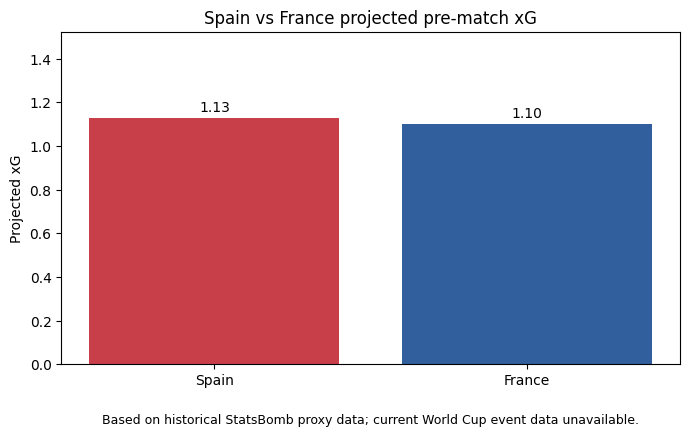

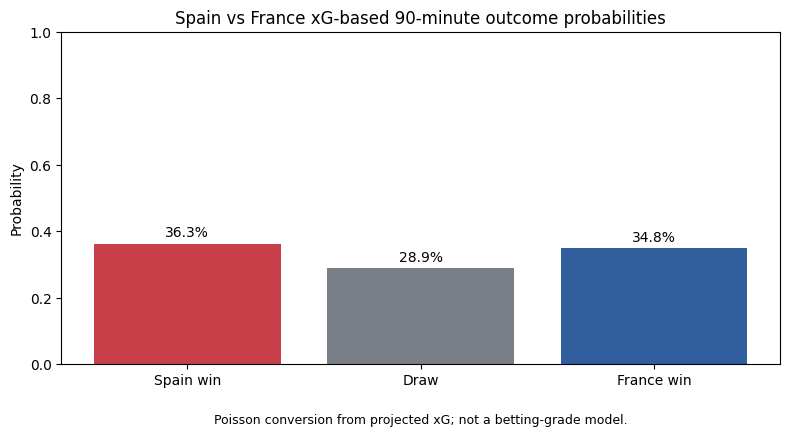

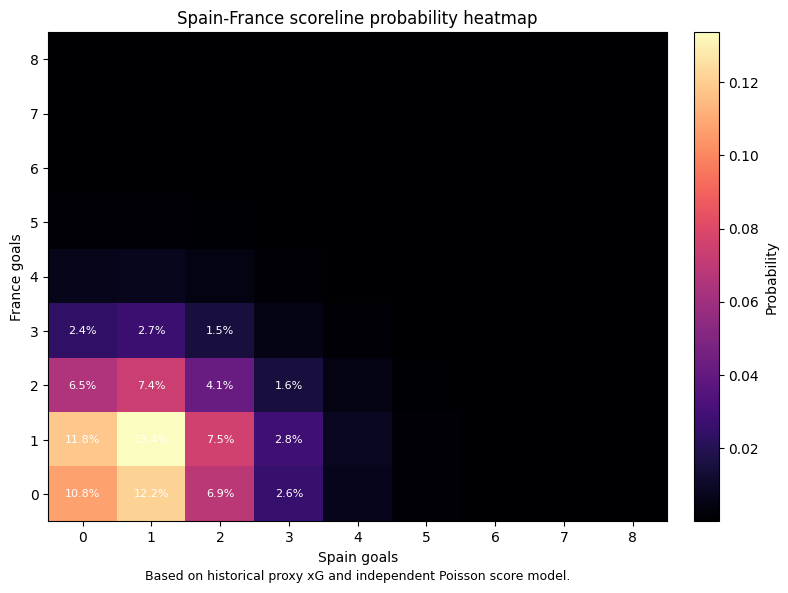

In [9]:
# Projected xG bar chart.
fig, ax = plt.subplots(figsize=(7, 4.5))
teams = [TARGET_MATCH["team_a"], TARGET_MATCH["team_b"]]
xg_values = [spain_projected_xg, france_projected_xg]
bars = ax.bar(teams, xg_values, color=["#c83f49", "#315f9d"])
ax.set_title("Spain vs France projected pre-match xG")
ax.set_ylabel("Projected xG")
ax.set_ylim(0, max(xg_values) * 1.35 if max(xg_values) > 0 else 1)
for bar, value in zip(bars, xg_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.03, f"{value:.2f}", ha="center")
ax.text(0.5, -0.18, "Based on historical StatsBomb proxy data; current World Cup event data unavailable.", transform=ax.transAxes, ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "spain_france_prematch_xg_bar.png", dpi=160, bbox_inches="tight")
plt.show()

# Outcome probability chart.
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = ["Spain win", "Draw", "France win"]
values = [spain_win_probability, draw_probability, france_win_probability]
bars = ax.bar(labels, values, color=["#c83f49", "#7a7f87", "#315f9d"])
ax.set_title("Spain vs France xG-based 90-minute outcome probabilities")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.1%}", ha="center")
ax.text(0.5, -0.18, "Poisson conversion from projected xG; not a betting-grade model.", transform=ax.transAxes, ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "spain_france_outcome_probabilities.png", dpi=160, bbox_inches="tight")
plt.show()

# Scoreline heatmap.
heatmap_df = scoreline_probabilities.pivot(index="france_goals", columns="spain_goals", values="probability").sort_index(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heatmap_df.values, cmap="magma", aspect="auto")
ax.set_title("Spain-France scoreline probability heatmap")
ax.set_xlabel("Spain goals")
ax.set_ylabel("France goals")
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)
for y in range(heatmap_df.shape[0]):
    for x in range(heatmap_df.shape[1]):
        value = heatmap_df.values[y, x]
        if value >= 0.015:
            ax.text(x, y, f"{value:.1%}", ha="center", va="center", color="white", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Probability")
ax.text(0.5, -0.12, "Based on historical proxy xG and independent Poisson score model.", transform=ax.transAxes, ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "spain_france_scoreline_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Interpretation Report

The report summarizes the data source, the xG model, how machine learning helped, and the final probability output.

In [10]:
def pct(value):
    return f"{float(value):.1%}"

report = f"""
# Spain vs France Pre-Match xG Prediction Report

## Data used

This experiment used local StatsBomb Open Data from `archive/data`, filtered to senior men's FIFA World Cup 2018 and 2022 plus UEFA Euro 2020 and 2024. The headline model used periods 1 and 2 only and excluded penalty shootouts by removing period 5.

Spain's recent sample covers **{spain_profile['sample_matches']}** matches from **{spain_profile['first_match_date']}** to **{spain_profile['last_match_date']}**. France's recent sample covers **{france_profile['sample_matches']}** matches from **{france_profile['first_match_date']}** to **{france_profile['last_match_date']}**.

## How machine learning helped

StatsBomb's `shot.statsbomb_xg` field is the machine-learning component in this workflow. It estimates the probability that each shot becomes a goal based on shot context. This notebook aggregates those supervised shot-level values into team-match xG, then uses a transparent pre-match model and Poisson score conversion.

## Projected xG

- Spain projected xG: **{spain_projected_xg:.2f}**
- France projected xG: **{france_projected_xg:.2f}**

## 90-minute outcome probabilities

- Spain win: **{pct(spain_win_probability)}**
- Draw: **{pct(draw_probability)}**
- France win: **{pct(france_win_probability)}**
- Most likely scoreline: **{prediction.loc[0, 'most_likely_scoreline']}** ({pct(prediction.loc[0, 'most_likely_scoreline_probability'])})

## Interpretation

From a data-analysis point of view, the model estimates the match from historical shot quality rather than outside commentary on current form. The result is low-confidence because it uses historical proxy tournaments, not current 2026 World Cup event data or confirmed lineups.

## Limitations

This is not a betting-grade forecast. It assumes independent Poisson scoring, neutral venue, no current lineup information, no injuries, no tactical news, and no current tournament event data. Extra-time and advancement probabilities are intentionally left out of this xG-first experiment.
""".strip()

report_path = OUTPUT_DIR / "spain_france_xg_prediction_report.md"
report_path.write_text(report, encoding="utf-8")
display(Markdown(report))
print(f"Saved {report_path}")

# Spain vs France Pre-Match xG Prediction Report

## Data used

This experiment used local StatsBomb Open Data from `archive/data`, filtered to senior men's FIFA World Cup 2018 and 2022 plus UEFA Euro 2020 and 2024. The headline model used periods 1 and 2 only and excluded penalty shootouts by removing period 5.

Spain's recent sample covers **10** matches from **2022-11-27** to **2024-07-14**. France's recent sample covers **10** matches from **2022-12-04** to **2024-07-09**.

## How machine learning helped

StatsBomb's `shot.statsbomb_xg` field is the machine-learning component in this workflow. It estimates the probability that each shot becomes a goal based on shot context. This notebook aggregates those supervised shot-level values into team-match xG, then uses a transparent pre-match model and Poisson score conversion.

## Projected xG

- Spain projected xG: **1.13**
- France projected xG: **1.10**

## 90-minute outcome probabilities

- Spain win: **36.3%**
- Draw: **28.9%**
- France win: **34.8%**
- Most likely scoreline: **1-1** (13.4%)

## Interpretation

From a data-analysis point of view, the model estimates the match from historical shot quality rather than outside commentary on current form. The result is low-confidence because it uses historical proxy tournaments, not current 2026 World Cup event data or confirmed lineups.

## Limitations

This is not a betting-grade forecast. It assumes independent Poisson scoring, neutral venue, no current lineup information, no injuries, no tactical news, and no current tournament event data. Extra-time and advancement probabilities are intentionally left out of this xG-first experiment.

Saved outputs\spain_france_xg_prediction\spain_france_xg_prediction_report.md


## 11. Final Checklist

This cell verifies the requested outputs and prints the final headline result.

In [11]:
required_outputs = [
    OUTPUT_DIR / "prematch_team_xg_dataset.csv",
    OUTPUT_DIR / "spain_france_xg_inputs.csv",
    OUTPUT_DIR / "spain_france_prematch_xg_prediction.csv",
    OUTPUT_DIR / "spain_france_scoreline_probabilities.csv",
    OUTPUT_DIR / "spain_france_xg_prediction_report.md",
    OUTPUT_DIR / "spain_france_prematch_xg_bar.png",
    OUTPUT_DIR / "spain_france_scoreline_heatmap.png",
    OUTPUT_DIR / "spain_france_outcome_probabilities.png",
]

checks = [
    ("StatsBomb local data loaded", not matches_df.empty),
    ("Shot-level statsbomb_xg extracted", team_xg_dataset["shot_xg_present_for"].sum() > 0),
    ("Period 5 shootout shots excluded from main model", 5 not in MAIN_PERIODS),
    ("Spain historical xG sample identified", spain_profile["sample_matches"] > 0),
    ("France historical xG sample identified", france_profile["sample_matches"] > 0),
    ("Pre-match projected xG calculated", np.isfinite(spain_projected_xg) and np.isfinite(france_projected_xg)),
    ("Poisson outcome probabilities calculated", np.isclose(spain_win_probability + draw_probability + france_win_probability, 1.0)),
    ("Output export", all(path.exists() for path in required_outputs)),
]

for label, ok in checks:
    print(f"[{'Completed' if ok else 'Failed'}] {label}")

print("\nHeadline xG prediction:")
print(f"Spain projected xG: {spain_projected_xg:.3f}")
print(f"France projected xG: {france_projected_xg:.3f}")
print(f"Spain win 90: {spain_win_probability:.3f}")
print(f"Draw 90: {draw_probability:.3f}")
print(f"France win 90: {france_win_probability:.3f}")
print(f"Most likely scoreline: {prediction.loc[0, 'most_likely_scoreline']}")
print("Confidence label: Low confidence")
print("Most important limitation: historical proxy data only; current 2026 World Cup event data unavailable.")

print("\nFinal output file paths:")
for path in required_outputs:
    print(f"- {path} [{'exists' if path.exists() else 'missing'}]")

[Completed] StatsBomb local data loaded
[Completed] Shot-level statsbomb_xg extracted
[Completed] Period 5 shootout shots excluded from main model
[Completed] Spain historical xG sample identified
[Completed] France historical xG sample identified
[Completed] Pre-match projected xG calculated
[Completed] Poisson outcome probabilities calculated
[Completed] Output export

Headline xG prediction:
Spain projected xG: 1.129
France projected xG: 1.100
Spain win 90: 0.363
Draw 90: 0.289
France win 90: 0.348
Most likely scoreline: 1-1
Confidence label: Low confidence
Most important limitation: historical proxy data only; current 2026 World Cup event data unavailable.

Final output file paths:
- outputs\spain_france_xg_prediction\prematch_team_xg_dataset.csv [exists]
- outputs\spain_france_xg_prediction\spain_france_xg_inputs.csv [exists]
- outputs\spain_france_xg_prediction\spain_france_prematch_xg_prediction.csv [exists]
- outputs\spain_france_xg_prediction\spain_france_scoreline_probabiliti